Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -98.5026
EM Iteration 100/300, ELBO: -75.3924
EM Iteration 150/300, ELBO: -57.8108
EM Iteration 200/300, ELBO: -46.7931
EM Iteration 250/300, ELBO: -40.2601
EM Iteration 300/300, ELBO: -36.5580

Optimization finished.

--- Initial Z ---
[-0.24892816  0.60123145  4.8778324  -4.60510616 -2.5409678   2.82091518
  2.32608818 -1.98106452 -1.7011305   1.35618074  3.16600534 -3.44602665
 -4.25286996  3.98021761  0.87397047 -1.22634768 -0.71421588  1.07238158
  4.09310551 -3.82626136]

--- Optimized Z ---
[-0.11400143  0.38547595  4.91033278 -4.88938541 -2.73430122  2.7578657
  2.16186786 -2.19054439 -1.71745728  1.54613531  3.31628119 -3.26476808
 -4.44811302  3.8678146   1.03255067 -1.18436798 -0.67474576  1.25700975
  4.4550185  -3.90913661]
-------------------


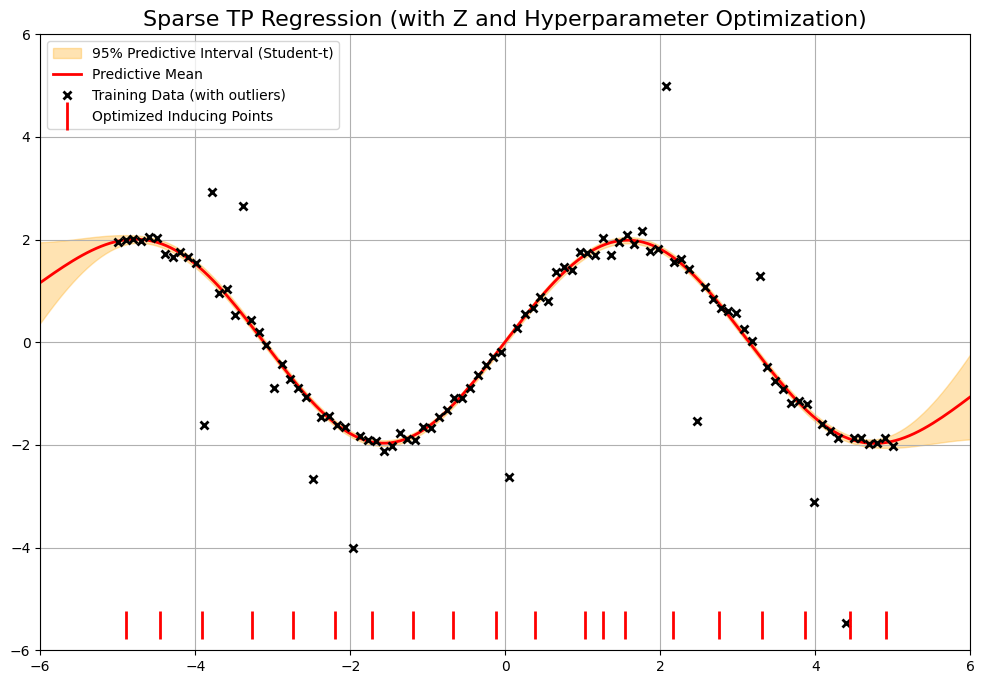

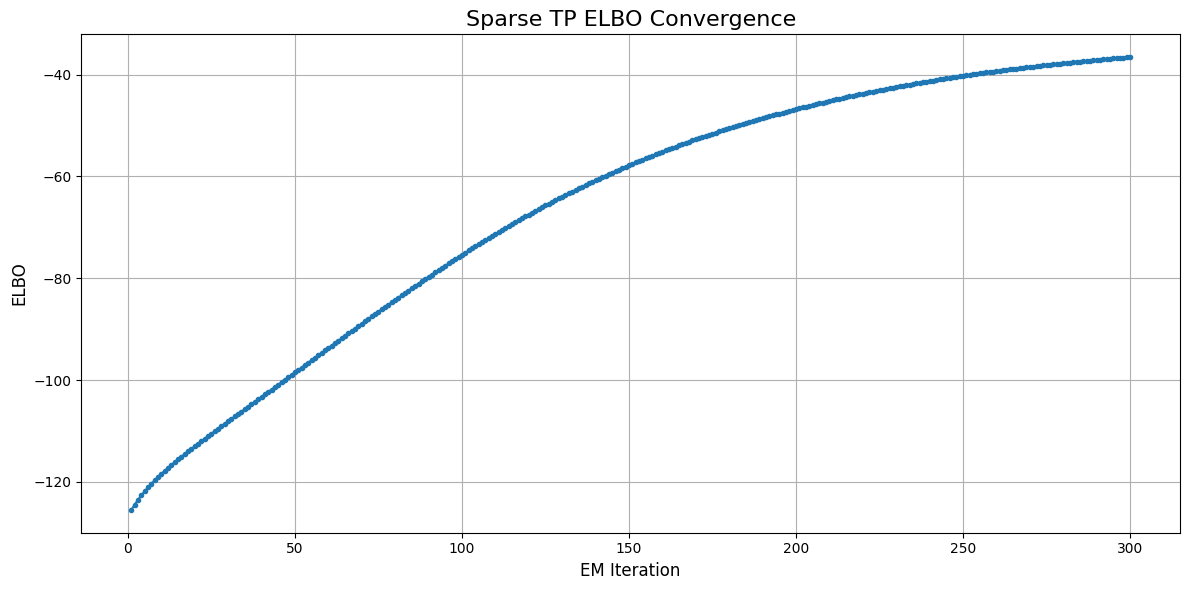

In [4]:
import torch
import torch.nn as nn 
import torch.optim as optim
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTFullBatch:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X = X
        # ★★★ 修正点1: yの形状を(N, 1)に統一 ★★★
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # ★★★ 修正点2: alpha/beta_lambdaの形状を(N, 1)に統一 ★★★
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _initialize_inducing_points(self):
        """
        Initializes inducing points using a Sobol sequence scaled to the data's bounds.
        """
        min_bounds = self.X.min(dim=0).values
        max_bounds = self.X.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)
    
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _update_q_lambda(self, params, L_ZZ, K_XZ, K_ZX, k_ii):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ KZZ_inv_m_u # Shape: (N, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r 

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        # ★★★ 修正点3: var_fの形状を(N, 1)に調整 ★★★
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)

        # y と expected_f_mean が (N, 1) なので .squeeze() は不要
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
        self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, params, K_ZZ, K_XZ, K_ZX):
        expected_r = self.alpha_r / self.beta_r
        # alpha/beta_lambdaは(N, 1)なのでsqueeze()が必要
        expected_lambda = self.alpha_lambda.squeeze() / self.beta_lambda.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX * c) @ K_XZ 
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)
        
        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        # yは(N, 1)なのでsqueeze()が必要
        y_term = K_ZX @ (self.y.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii):
        self._update_q_lambda(params, L_ZZ, K_XZ, K_ZX, k_ii)
        self._update_q_r(params, L_ZZ)
        self._update_q_u(params, K_ZZ, K_XZ, K_ZX)

    def _e_step(self, cavi_max_iter=20, cavi_tol=1e-6):
        with torch.no_grad(): 
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            K_ZX = K_XZ.T
            k_ii = params['variance'].expand(self.X.shape[0])

            for _ in range(cavi_max_iter):
                m_u_prev = self.m_u.clone()
                self._cavi_step(params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii)
                m_u_rel_change = torch.norm(self.m_u - m_u_prev) / torch.norm(m_u_prev)
                if m_u_rel_change < cavi_tol:
                    break

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01):
        """Runs the full Variational EM algorithm."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        K_ZX = K_XZ.T
        k_ii = params['variance'].expand(self.X.shape[0])
        
        L_S = torch.linalg.cholesky(self.S_u)

        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T

        # --- 1. Expected Log-Likelihood ---
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        expected_f_mean = K_XZ @ KZZ_inv_m_u # Shape: (N, 1)
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        # ★★★ 修正点4: var_fの形状を(N, 1)に調整 ★★★
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        # yとexpected_f_meanは(N, 1)なのでsqueeze不要
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)

        # --- 2. KL Divergences ---
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u 
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (
            -logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + \
            expected_r * expected_u_quadratic - self.M
        ).squeeze()
        
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        



if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import math # 不要ですが、他のコードとの互換性のため残すこともあります

    # --- グローバル設定 ---
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # ノイズと外れ値の追加
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # 手動でさらに強い外れ値を追加
    y_train[30] = -4.0
    y_train[70] = 5.0

    # --- 2. モデルのセットアップ ---
    
    # 誘導点の数を指定
    M = 20
    
    # モデルのインスタンス化 (Z_initial の代わりに M を渡す)
    model = SparseTPRTFullBatch(
        X=X_train,
        y=y_train,
        M=M, # <- ここが変更点
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 最適化前の初期誘導点を保存しておく
    initial_Z = model.Z.clone().detach()

    # --- 3. モデルの学習とELBOの記録 ---
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # --- 4. 誘導点の位置を表示 ---
    print("\n--- Initial Z ---")
    print(initial_Z.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # --- 5. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 6. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))

    # 予測分布（Student-t）の95%信頼区間を計算
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    # scipy.stats.tを使ってパーセント点関数(ppf)を計算
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 7. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('EM Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

Starting Variational EM optimization...


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_3768634/1760219560.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2255.)
  self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]
EM Iteration 100/100, ELBO: 130.0007: 100%|██████████| 100/100 [00:00<00:00, 132.57it/s]



Optimization finished.


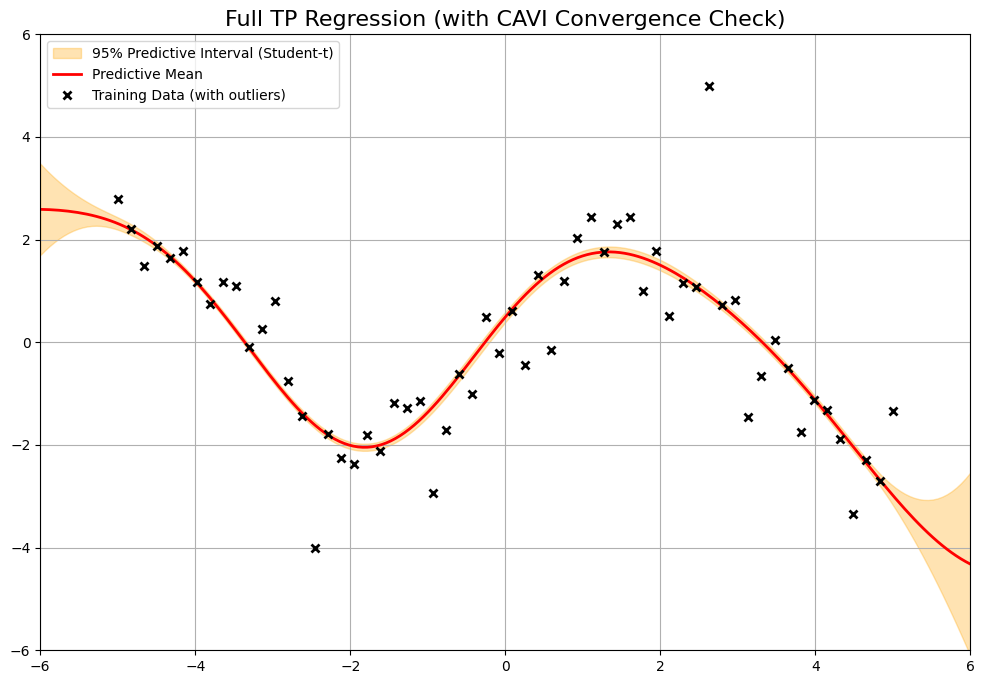

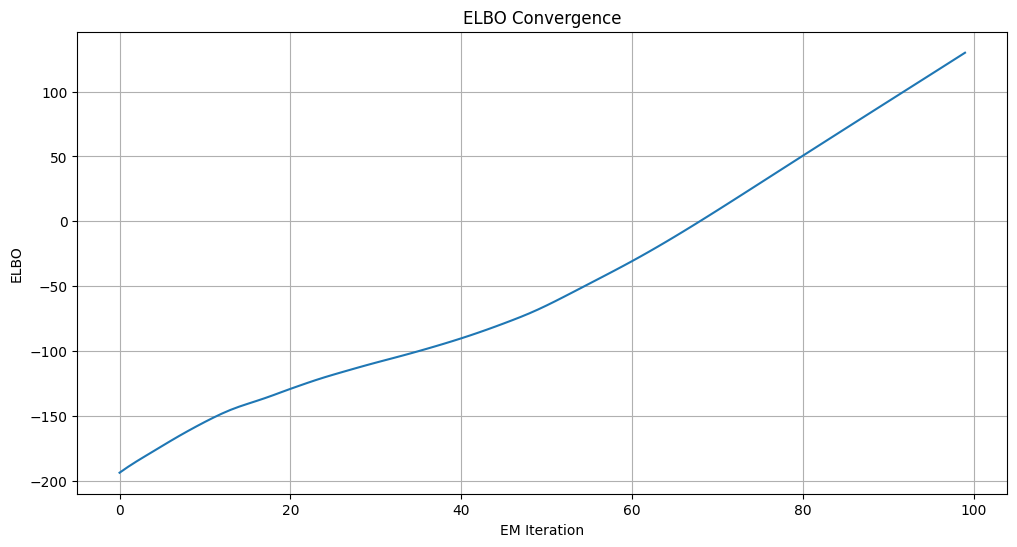

In [1]:
import torch
import torch.nn as nn
import math
import tqdm

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRTFullBatch:
    """
    Implementation of the full (non-sparse) Student-t Process regression model.
    This version is aligned with the structure of the SparseTPRTFullBatch class.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        
        self.X = X
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))

        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.L_f = torch.eye(self.N, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma_sq": torch.exp(self.log_likelihood_sigma_sq),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }

    def _update_q_lambda(self, params):
        S_f = self.L_f @ self.L_f.T
        var_f = S_f.diag().unsqueeze(1)
        expected_f_mean = self.m_f

        self.alpha_lambda = params['nu_e'] / 2.0 + 0.5
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.beta_lambda = params['nu_e'] / 2.0 + (1.0 / (2.0 * params['sigma_sq'])) * expected_sq_error

    def _update_q_r(self, params, Lxx):
        S_f = self.L_f @ self.L_f.T
        
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        
        trace_term = torch.trace(Kxx_inv_Sf)
        mean_term = self.m_f.T @ Kxx_inv_mf
        expected_f_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.N / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_f_quadratic_form.squeeze()

    def _update_q_f(self, params, Lxx):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda

        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = expected_r * Kxx_inv + torch.diag(expected_lambda.squeeze() / params['sigma_sq'])
        
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]

        temp_vec = (expected_lambda / params['sigma_sq']) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, params, Lxx):
        self._update_q_lambda(params)
        self._update_q_r(params, Lxx)
        self._update_q_f(params, Lxx)
        
    def _e_step(self, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step by running CAVI updates until convergence or max_iter.
        Convergence is checked only on the mean parameter m_f.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            ### MODIFIED: Convergence check logic based only on m_f ###
            for i in range(cavi_max_iter):
                m_f_old = self.m_f.clone()

                self._cavi_step(params, Lxx)

                # Check for convergence using relative change of m_f
                m_f_rel_change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-8)

                if m_f_rel_change < cavi_tol:
                    # print(f"  (CAVI converged in {i+1} iterations)") # Optional: for debugging
                    break

    def _m_step(self, optimizer):
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01):
        """Fits the model using the Variational EM algorithm."""
        optimizer = torch.optim.Adam([
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma_sq, self.log_nu_f, self.log_nu_e
        ], lr=lr)

        elbo_history = []
        print("Starting Variational EM optimization...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            pbar.set_description(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")

        print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        S_f = self.L_f @ self.L_f.T

        # Expected Log Likelihood
        E_q_f = self.m_f
        Var_q_f = S_f.diag().unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        e_log_lik = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * self.N * torch.log(params['sigma_sq']) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / params['sigma_sq'] * torch.sum(E_lambda * expected_sq_error)

        # KL Divergence for f and r
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_f = -torch.sum(torch.log(torch.diag(self.L_f)))
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        quad_form_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        E_quad_form_f = trace_term + quad_form_term
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * log_det_Kxx + 0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        E_log_p_r = p_alpha_r * torch.log(p_beta_r) - torch.lgamma(p_alpha_r) + \
                    (p_alpha_r - 1) * E_log_r - p_beta_r * E_r
        kl_f_r_grouped = (log_q_f + log_q_r) - (E_log_p_f_r + E_log_p_r)

        # KL Divergence for lambda_i
        p_alpha_lambda, p_beta_lambda = params['nu_e'] / 2.0, params['nu_e'] / 2.0
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(p_alpha_lambda) - p_alpha_lambda * torch.log(p_beta_lambda)) - \
                    (self.alpha_lambda - p_alpha_lambda) * E_log_lambda + \
                    (self.beta_lambda - p_beta_lambda) * E_lambda
        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r_grouped - kl_lambda_sum
        return elbo

    def predict(self, X_test):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()
            
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu

if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    torch.set_default_dtype(torch.float64)

    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.3
    y_train = y_true + noise
    
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = TPRTFullBatch(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1.0
    )

    # 3. Fit the model
    elbo_history = model.fit(max_iter_global=100, cavi_max_iter=25, cavi_tol=1e-6, lr=0.05)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item() if not torch.isnan(pred_nu) and pred_nu > 0 else 2.0
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Full TP Regression (with CAVI Convergence Check)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history)
    plt.title("ELBO Convergence")
    plt.xlabel("EM Iteration")
    plt.ylabel("ELBO")
    plt.grid(True)
    
    plt.show()

Starting Variational EM optimization for 1000 epochs with batch size 50...
Epoch 10/1000, Final Batch ELBO: -250.1585
Epoch 20/1000, Final Batch ELBO: -133.7701
Epoch 30/1000, Final Batch ELBO: -138.5499
Epoch 40/1000, Final Batch ELBO: -119.3727
Epoch 50/1000, Final Batch ELBO: -62.8927
Epoch 60/1000, Final Batch ELBO: -21.7153
Epoch 70/1000, Final Batch ELBO: -24.4345
Epoch 80/1000, Final Batch ELBO: -42.1160
Epoch 90/1000, Final Batch ELBO: -90.3095
Epoch 100/1000, Final Batch ELBO: -0.3628
Epoch 110/1000, Final Batch ELBO: -0.1977
Epoch 120/1000, Final Batch ELBO: 53.8296
Epoch 130/1000, Final Batch ELBO: -19.6555
Epoch 140/1000, Final Batch ELBO: -29.8566
Epoch 150/1000, Final Batch ELBO: -99.5642
Epoch 160/1000, Final Batch ELBO: -48.8343
Epoch 170/1000, Final Batch ELBO: 16.4821
Epoch 180/1000, Final Batch ELBO: -0.6067
Epoch 190/1000, Final Batch ELBO: 13.0297
Epoch 200/1000, Final Batch ELBO: -36.8093
Epoch 210/1000, Final Batch ELBO: -54.5333
Epoch 220/1000, Final Batch ELBO:

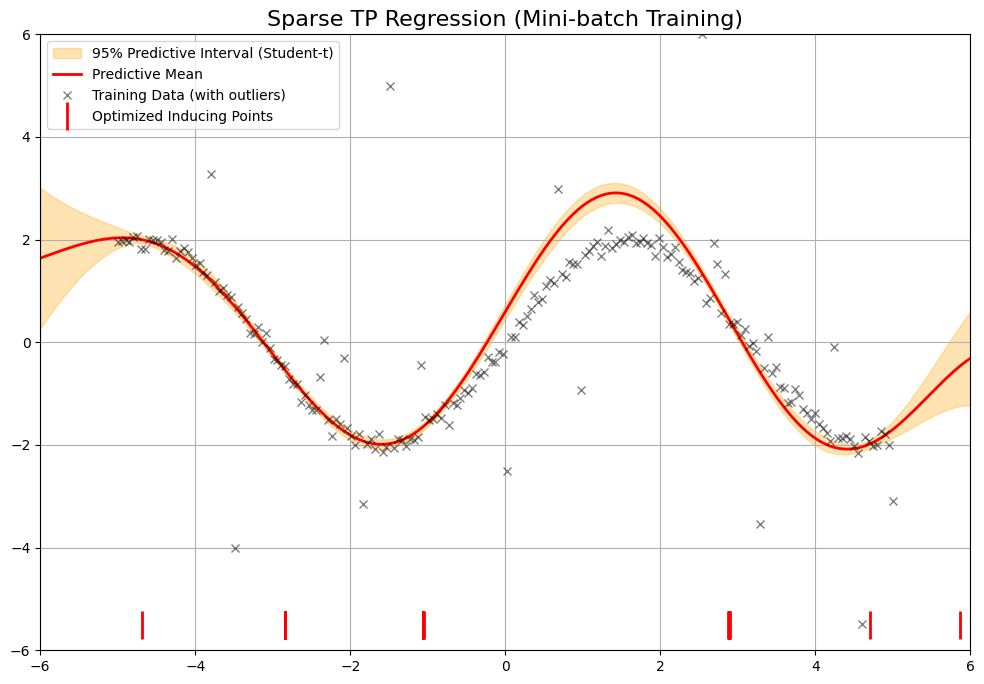

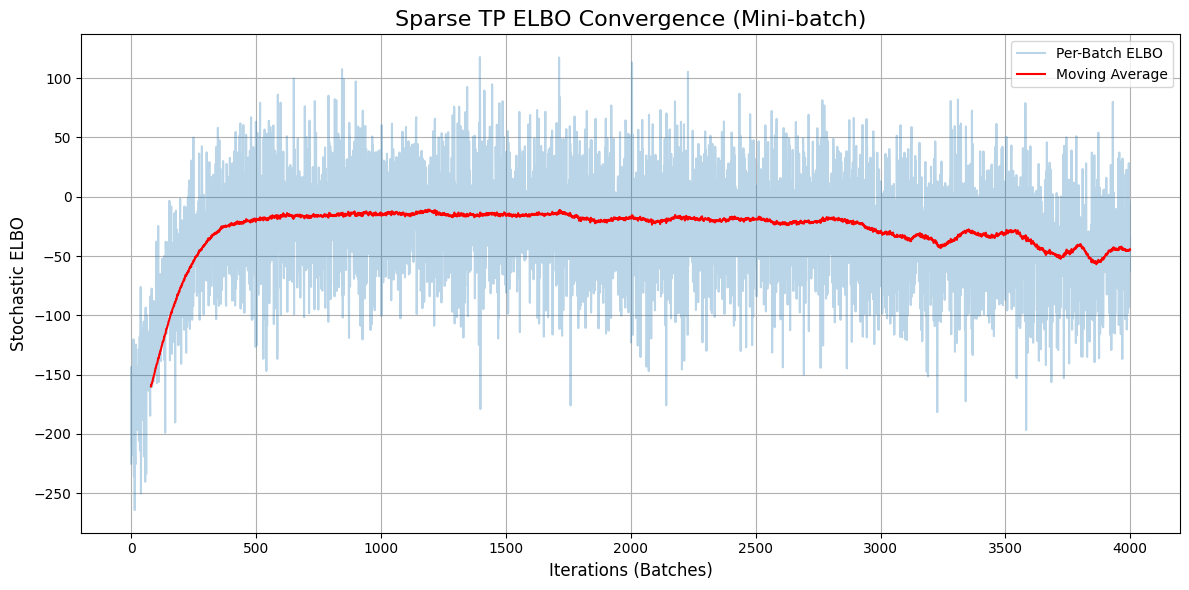

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTMiniBatch:
    """
    Implementation of Variational EM for Student-t Process Regression with Mini-batching.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points
              using a stochastic estimate of the ELBO.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Full training inputs, shape (N, D).
            y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X_full = X # Keep full data for reference (e.g., initialization)
        self.y_full = y.view(-1, 1) # Keep full data for reference
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # LOCAL variational parameters (alpha_lambda, beta_lambda) are computed on-the-fly for each batch

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # === E-Step Methods (now operate on a batch) ===
    def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
        beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
        return alpha_lambda_batch, beta_lambda_batch

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX_batch * c) @ K_XZ_batch
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)

        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        y_term = K_ZX_batch @ (y_batch.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol=1e-5):
        # Kernels relevant to the batch
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(X_batch.shape[0])

        # Local vars for lambda are re-calculated each time
        alpha_lambda_batch, beta_lambda_batch = None, None

        for _ in range(cavi_max_iter):
            m_u_prev = self.m_u.clone()  # Store previous m_u for convergence check
            alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
            self._update_q_r(params, L_ZZ) # Depends on global S_u, m_u
            self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch) # Uses batch data
            m_u_rel_change = torch.norm(self.m_u - m_u_prev) / torch.norm(m_u_prev)
            if m_u_rel_change < cavi_tol:
                break

        return alpha_lambda_batch, beta_lambda_batch


    def _e_step(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
            alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol)

        return alpha_lambda_batch, beta_lambda_batch


    # === M-Step Methods (now operate on a batch) ===
    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        optimizer.zero_grad()
        # Pass batch-specific variational parameters to ELBO calculation
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
    
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        B = X_batch.shape[0] # Batch size
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(B)
        
        # --- 1. Expected Log-Likelihood (Data-dependent term) ---
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        log_lik = log_lik_batch * (self.N / B)

        # --- 2. KL Divergences ---
        # KL[q(r) || p(r)] (Global term, NOT scaled)
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)] (Global term, NOT scaled)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
        # KL[q(lambda) || p(lambda)] (Data-dependent term)
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        kl_lambda = kl_lambda_batch * (self.N / B)

        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, cavi_tol=1e-9, lr=0.01):
        """Runs the full Variational EM algorithm using mini-batches."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        # Create DataLoader for mini-batching
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):

                # print(f"Processing batch {i+1}/{len(dataloader)} in epoch {epoch+1}...")

                # E-Step: Update global variational params and get local ones for the batch
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
                
                # M-Step: Update hyperparameters using the stochastic ELBO from the batch
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test. (No changes needed here)
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        
        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=1000, batch_size=50, cavi_max_iter=20, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

Starting Variational EM optimization for 1000 epochs with batch size 50...
Epoch 10/1000, Final Batch ELBO: -250.1585
Epoch 20/1000, Final Batch ELBO: -133.7701
Epoch 30/1000, Final Batch ELBO: -138.5499
Epoch 40/1000, Final Batch ELBO: -119.3727
Epoch 50/1000, Final Batch ELBO: -62.8927
Epoch 60/1000, Final Batch ELBO: -21.7153
Epoch 70/1000, Final Batch ELBO: -24.4345
Epoch 80/1000, Final Batch ELBO: -42.1160
Epoch 90/1000, Final Batch ELBO: -90.3095
Epoch 100/1000, Final Batch ELBO: -0.3628
Epoch 110/1000, Final Batch ELBO: -0.1977
Epoch 120/1000, Final Batch ELBO: 53.8296
Epoch 130/1000, Final Batch ELBO: -19.6555
Epoch 140/1000, Final Batch ELBO: -29.8566
Epoch 150/1000, Final Batch ELBO: -99.5642
Epoch 160/1000, Final Batch ELBO: -48.8343
Epoch 170/1000, Final Batch ELBO: 16.4821
Epoch 180/1000, Final Batch ELBO: -0.6067
Epoch 190/1000, Final Batch ELBO: 13.0297
Epoch 200/1000, Final Batch ELBO: -36.8093
Epoch 210/1000, Final Batch ELBO: -54.5333
Epoch 220/1000, Final Batch ELBO:

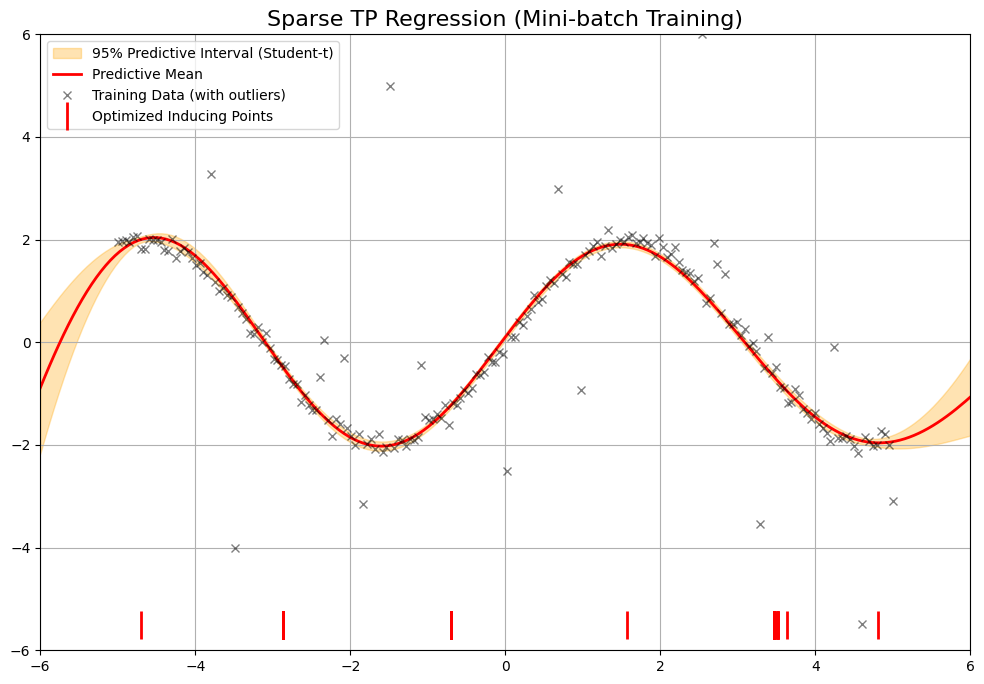

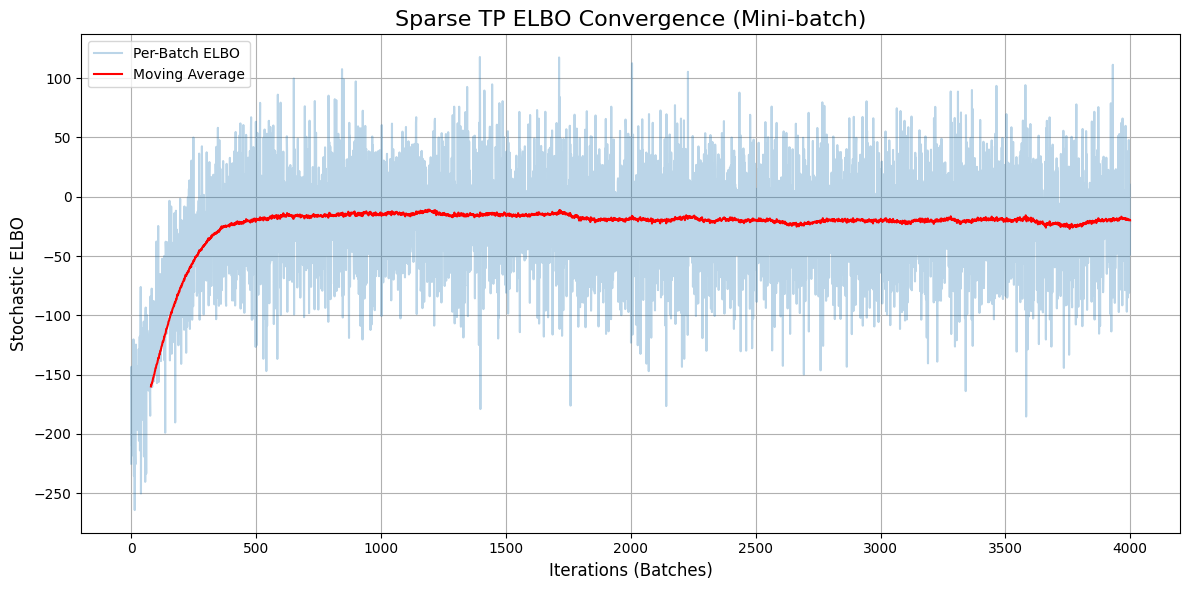

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTMiniBatch:
    """
    Implementation of Variational EM for Student-t Process Regression with Mini-batching.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points
              using a stochastic estimate of the ELBO.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Full training inputs, shape (N, D).
            y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X_full = X # Keep full data for reference (e.g., initialization)
        self.y_full = y.view(-1, 1) # Keep full data for reference
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # LOCAL variational parameters (alpha_lambda, beta_lambda) are computed on-the-fly for each batch

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # === E-Step Methods (now operate on a batch) ===
    def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
        beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
        return alpha_lambda_batch, beta_lambda_batch

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX_batch * c) @ K_XZ_batch
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)

        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        y_term = K_ZX_batch @ (y_batch.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter):
        # Kernels relevant to the batch
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(X_batch.shape[0])

        # Local vars for lambda are re-calculated each time
        alpha_lambda_batch, beta_lambda_batch = None, None

        for _ in range(cavi_max_iter):
            alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
            self._update_q_r(params, L_ZZ) # Depends on global S_u, m_u
            self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch) # Uses batch data

        return alpha_lambda_batch, beta_lambda_batch


    def _e_step(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
            alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter)

        return alpha_lambda_batch, beta_lambda_batch


    # === M-Step Methods (now operate on a batch) ===
    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        optimizer.zero_grad()
        # Pass batch-specific variational parameters to ELBO calculation
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
    
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        B = X_batch.shape[0] # Batch size
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(B)
        
        # --- 1. Expected Log-Likelihood (Data-dependent term) ---
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        log_lik = log_lik_batch * (self.N / B)

        # --- 2. KL Divergences ---
        # KL[q(r) || p(r)] (Global term, NOT scaled)
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)] (Global term, NOT scaled)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
        # KL[q(lambda) || p(lambda)] (Data-dependent term)
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        kl_lambda = kl_lambda_batch * (self.N / B)

        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, lr=0.01):
        """Runs the full Variational EM algorithm using mini-batches."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        # Create DataLoader for mini-batching
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):

                # print(f"Processing batch {i+1}/{len(dataloader)} in epoch {epoch+1}...")

                # E-Step: Update global variational params and get local ones for the batch
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter)
                
                # M-Step: Update hyperparameters using the stochastic ELBO from the batch
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test. (No changes needed here)
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        
        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=1000, batch_size=50, cavi_max_iter=20, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()